# Exploratory Data Analysis (EDA)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("HARRIS COUNTY - EXPLORATORY DATA ANALYSIS")
print("=" * 80)

df = pd.read_csv(r"C:\Users\Sai\Downloads\TX_Harris_Project\Data\Processed\harris_county_clean.csv", low_memory=False)

print(f"Loaded {len(df):,} properties\n")

print("1. TARGET VARIABLE DISTRIBUTION")
print("-" * 80)
print(f"tot_appr_val statistics:")
print(f"  Mean:      ${df['tot_appr_val'].mean():>12,.0f}")
print(f"  Median:    ${df['tot_appr_val'].median():>12,.0f}")
print(f"  Std Dev:   ${df['tot_appr_val'].std():>12,.0f}")
print(f"  25th pct:  ${df['tot_appr_val'].quantile(0.25):>12,.0f}")
print(f"  75th pct:  ${df['tot_appr_val'].quantile(0.75):>12,.0f}")
print(f"\n  Skewness: {df['tot_appr_val'].skew():.2f} (right-skewed, typical for property values)")

HARRIS COUNTY - EXPLORATORY DATA ANALYSIS
Loaded 83,595 properties

1. TARGET VARIABLE DISTRIBUTION
--------------------------------------------------------------------------------
tot_appr_val statistics:
  Mean:      $     558,560
  Median:    $     243,195
  Std Dev:   $   1,705,047
  25th pct:  $     127,558
  75th pct:  $     540,601

  Skewness: 18.81 (right-skewed, typical for property values)


In [23]:
print("\n2. PROPERTY TYPE COMPARISON")
print("-" * 80)
type_analysis = df.groupby('property_type_group').agg({
    'acct': 'count',
    'tot_appr_val': ['mean', 'median', 'min', 'max'],
    'bld_ar': 'mean',
    'land_ar': 'mean'
}).round(0)

print(type_analysis)


2. PROPERTY TYPE COMPARISON
--------------------------------------------------------------------------------
                      acct tot_appr_val                             bld_ar  \
                     count         mean    median    min       max    mean   
property_type_group                                                          
Agricultural         47558     443953.0  269312.0  10716   9256530  1857.0   
Commercial           27645     727961.0  175000.0      1  96761685  5880.0   
Other                 8392     650009.0  184810.0      2  64495523  5948.0   

                      land_ar  
                         mean  
property_type_group            
Agricultural          10147.0  
Commercial            40272.0  
Other                101251.0  


In [24]:
print("\n3. FEATURE CORRELATIONS WITH TARGET")
print("-" * 80)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('acct')
numeric_cols.remove('yr')

correlations = df[numeric_cols].corr()['tot_appr_val'].sort_values(ascending=False)
print("\nTop 10 features correlated with property value:")
print(correlations.head(10))


3. FEATURE CORRELATIONS WITH TARGET
--------------------------------------------------------------------------------

Top 10 features correlated with property value:
tot_appr_val          1.000000
tot_mkt_val           0.996463
prior_tot_appr_val    0.991880
prior_bld_val         0.841229
bld_ar                0.758503
prior_land_val        0.700829
total_area            0.187988
land_ar               0.141959
acreage               0.141959
is_commercial         0.069838
Name: tot_appr_val, dtype: float64


In [25]:
print("\n4. TOP NEIGHBORHOODS BY VALUE")
print("-" * 80)
neighborhood_analysis = df.groupby('Neighborhood_Grp').agg({
    'acct': 'count',
    'tot_appr_val': ['mean', 'median']
}).round(0)
neighborhood_analysis.columns = ['Count', 'Avg_Value', 'Median_Value']
neighborhood_analysis = neighborhood_analysis.sort_values('Avg_Value', ascending=False).head(15)
print(neighborhood_analysis)


4. TOP NEIGHBORHOODS BY VALUE
--------------------------------------------------------------------------------
                  Count  Avg_Value  Median_Value
Neighborhood_Grp                                
1645                 21  3009765.0     3218869.0
1218                735  2532923.0     2296360.0
1209                107  2450465.0     2188188.0
25016                 1  2032147.0     2032147.0
1627                 33  1580928.0     1576236.0
1214                 33  1577567.0     1513698.0
25013                17  1397358.0     1493341.0
1212                 39  1365213.0     1319522.0
1208                 16  1354565.0     1227472.0
1                    93  1344739.0      614688.0
1617               1048  1134956.0     1050922.0
1203                 96  1130570.0      947294.0
1621                671  1110299.0      949451.0
0                 20997  1103533.0      359648.0
1210                625  1073160.0     1069939.0


In [26]:
print("\n5. COMMERCIAL VS AGRICULTURAL PROPERTIES")
print("-" * 80)
commercial = df[df['property_type_group'] == 'Commercial']
agricultural = df[df['property_type_group'] == 'Agricultural']

print(f"\nCommercial properties (n={len(commercial):,}):")
print(f"  Avg value:         ${commercial['tot_appr_val'].mean():>12,.0f}")
print(f"  Median value:      ${commercial['tot_appr_val'].median():>12,.0f}")
print(f"  Avg building area:{commercial['bld_ar'].mean():>12,.0f} sqft")
print(f"  Avg land area:     {commercial['land_ar'].mean():>12,.0f} sqft")

print(f"\nAgricultural properties (n={len(agricultural):,}):")
print(f"  Avg value:         ${agricultural['tot_appr_val'].mean():>12,.0f}")
print(f"  Median value:      ${agricultural['tot_appr_val'].median():>12,.0f}")
print(f"  Avg building area:{agricultural['bld_ar'].mean():>12,.0f} sqft")
print(f"  Avg land area:     {agricultural['land_ar'].mean():>12,.0f} sqft")


5. COMMERCIAL VS AGRICULTURAL PROPERTIES
--------------------------------------------------------------------------------

Commercial properties (n=27,645):
  Avg value:         $     727,961
  Median value:      $     175,000
  Avg building area:       5,880 sqft
  Avg land area:           40,272 sqft

Agricultural properties (n=47,558):
  Avg value:         $     443,953
  Median value:      $     269,312
  Avg building area:       1,857 sqft
  Avg land area:           10,147 sqft


In [27]:
print("\n6. BUILDING AREA IMPACT")
print("-" * 80)
df_with_bldg = df[df['bld_ar'] > 0]
correlation = df_with_bldg['bld_ar'].corr(df_with_bldg['tot_appr_val'])
print(f"Correlation between building area and property value: {correlation:.3f}")
print(f"Properties with building area: {len(df_with_bldg):,} ({len(df_with_bldg)/len(df)*100:.1f}%)")


6. BUILDING AREA IMPACT
--------------------------------------------------------------------------------
Correlation between building area and property value: 0.844
Properties with building area: 62,060 (74.2%)


In [28]:
print("\n7. DATA QUALITY")
print("-" * 80)
print(f"Missing values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values!")


7. DATA QUALITY
--------------------------------------------------------------------------------
Missing values:
No missing values!


In [29]:
print("\n8. YEAR-OVER-YEAR VALUE CHANGES")
print("-" * 80)
print(f"Average value change: {df['value_change_pct'].mean():>8.2f}%")
print(f"Median value change:  {df['value_change_pct'].median():>8.2f}%")
print(f"Properties with increases: {(df['value_change_pct'] > 0).sum():,}")
print(f"Properties with decreases: {(df['value_change_pct'] < 0).sum():,}")
print(f"Properties unchanged:      {(df['value_change_pct'] == 0).sum():,}")


8. YEAR-OVER-YEAR VALUE CHANGES
--------------------------------------------------------------------------------
Average value change:     7.22%
Median value change:      0.20%
Properties with increases: 42,947
Properties with decreases: 18,952
Properties unchanged:      21,696



9. CREATING VISUALIZATIONS...
--------------------------------------------------------------------------------


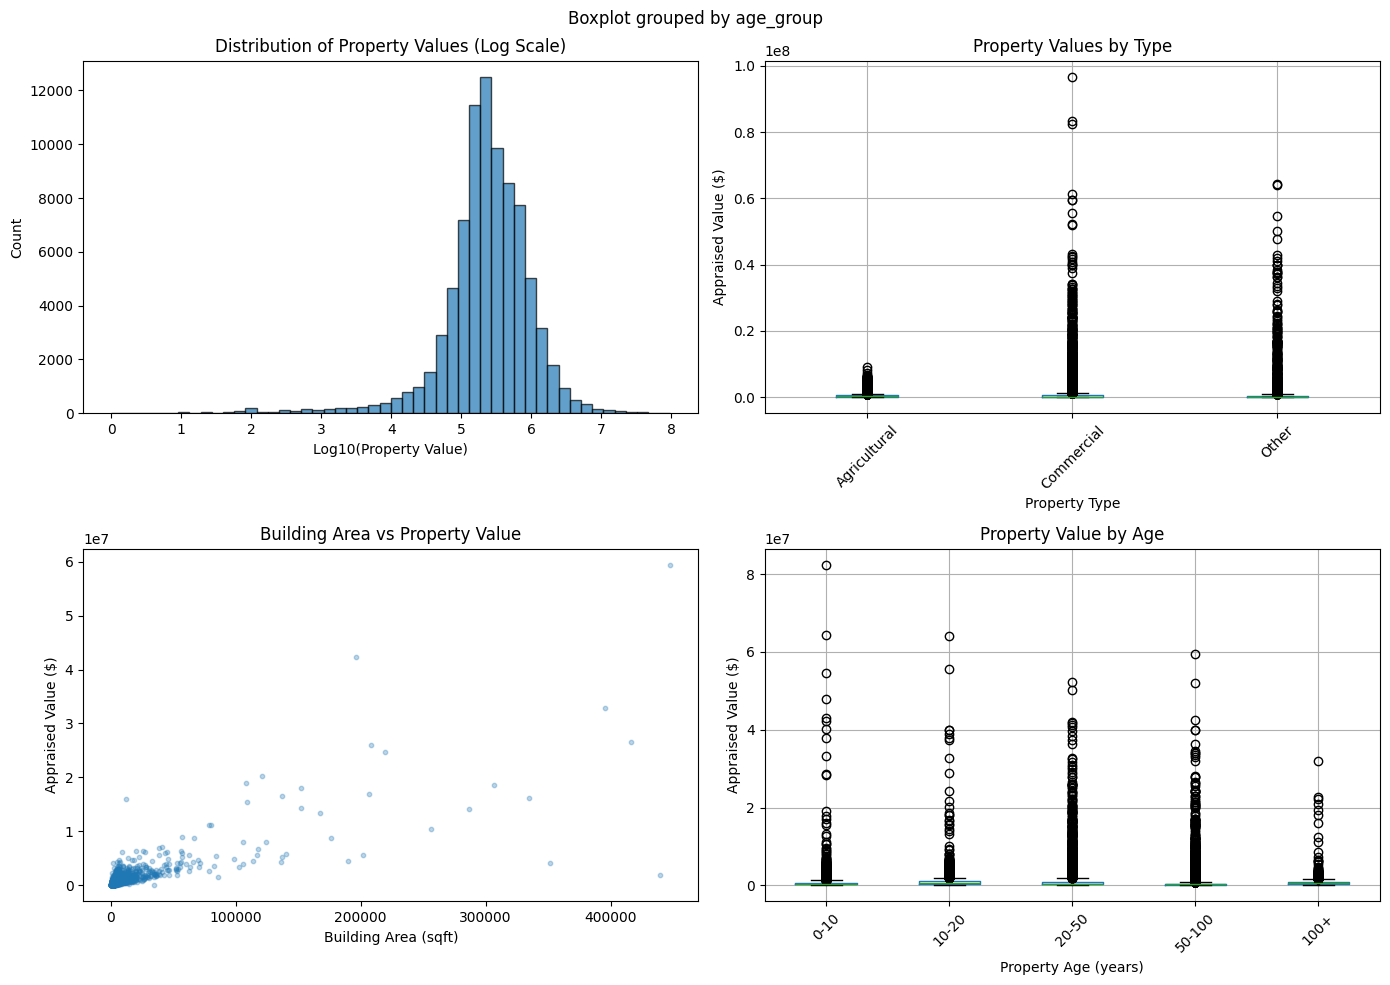

In [30]:
print("\n9. CREATING VISUALIZATIONS...")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Harris County Property Tax Analysis', fontsize=16, fontweight='bold')

# Plot 1: Value distribution (log scale)
ax1 = axes[0, 0]
ax1.hist(np.log10(df['tot_appr_val']), bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Log10(Property Value)')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Property Values (Log Scale)')

# Plot 2: Value by property type
ax2 = axes[0, 1]
df.boxplot(column='tot_appr_val', by='property_type_group', ax=ax2)
ax2.set_xlabel('Property Type')
ax2.set_ylabel('Appraised Value ($)')
ax2.set_title('Property Values by Type')
plt.sca(ax2)
plt.xticks(rotation=45)

# Plot 3: Building area vs value
ax3 = axes[1, 0]
sample = df[df['bld_ar'] > 0].sample(min(5000, len(df[df['bld_ar'] > 0])))
ax3.scatter(sample['bld_ar'], sample['tot_appr_val'], alpha=0.3, s=10)
ax3.set_xlabel('Building Area (sqft)')
ax3.set_ylabel('Appraised Value ($)')
ax3.set_title('Building Area vs Property Value')

# Plot 4: Property age vs value
ax4 = axes[1, 1]
age_groups = pd.cut(df['property_age'], bins=[0, 10, 20, 50, 100, 200], 
                     labels=['0-10', '10-20', '20-50', '50-100', '100+'])
df_with_age = df.copy()
df_with_age['age_group'] = age_groups

df_with_age.boxplot(column='tot_appr_val', by='age_group', ax=ax4)
ax4.set_xlabel('Property Age (years)')
ax4.set_ylabel('Appraised Value ($)')
ax4.set_title('Property Value by Age')
plt.sca(ax4)
plt.xticks(rotation=45)



plt.tight_layout()
plt.savefig(r'C:\Users\Sai\Downloads\TX_Harris_Project\eda_analysis.png', dpi=300, bbox_inches='tight')

In [31]:
print("\n" + "=" * 80)
print("EXPLORATORY ANALYSIS COMPLETE")
print("=" * 80)


EXPLORATORY ANALYSIS COMPLETE
